# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Youssef Ahmed Afify 
**Student ID:** 1200883

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(32)
tf.random.set_seed(32)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [25]:
df = pd.read_csv("kidney_disease.csv")


df["classification"] = df["classification"].str.strip()
y = (df["classification"] == "ckd").astype(int)

print("--- Target Distribution ---")
print(y.value_counts().rename({1: "CKD (1)", 0: "Not CKD (0)"}))
print(f"CKD prevalence : {y.mean()*100:.1f}%")

# Dropping Categorical Data
X = df.select_dtypes(include=[np.number]).drop(columns=["id"], errors="ignore")

print(f"\n--- Numerical Features Retained ({X.shape[1]}) ---")
print(X.columns.tolist())


print(f"\nMissing values per feature:\n{X.isnull().sum()[X.isnull().sum() > 0]}")

# ── 80/20 stratified train / validation split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

train_medians = X_train_raw.median()
X_train_filled = X_train_raw.fillna(train_medians)
X_val_filled   = X_val_raw.fillna(train_medians)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_val_scaled   = scaler.transform(X_val_filled)

print("\n--- Split Sizes --")
print(f"Training set   : {X_train_scaled.shape}")
print(f"Validation set : {X_val_scaled.shape}")

N_FEATURES = X_train_scaled.shape[1]
N_PATIENTS = X_train_scaled.shape[0]
print(f"\nN_FEATURES={N_FEATURES} | N_TRAIN={N_PATIENTS}")


--- Target Distribution ---
classification
CKD (1)        250
Not CKD (0)    150
Name: count, dtype: int64
CKD prevalence : 62.5%

--- Numerical Features Retained (11) ---
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Missing values per feature:
age      9
bp      12
sg      47
al      46
su      49
bgr     44
bu      19
sc      17
sod     87
pot     88
hemo    52
dtype: int64

--- Split Sizes --
Training set   : (320, 11)
Validation set : (80, 11)

N_FEATURES=11 | N_TRAIN=320


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

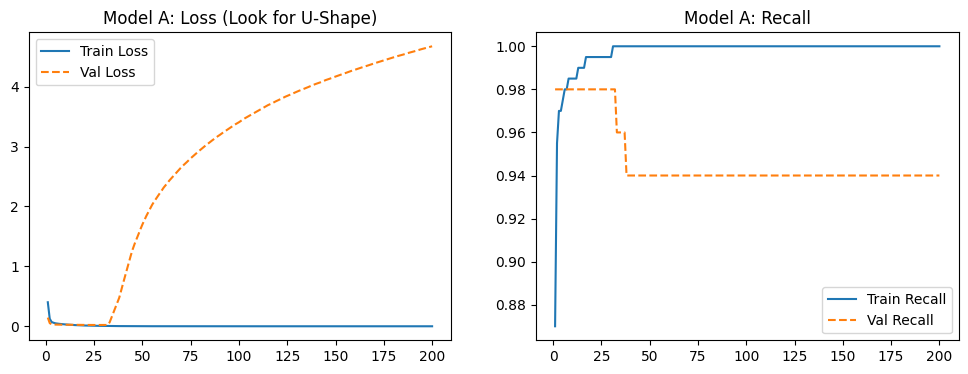

In [20]:
# Deliberately over-parameterized
model_A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# High learning rate SGD often causes the "U-shape" loss failure
model_A.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.Recall(name='recall')]
)


history_A = model_A.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200, batch_size=32, verbose=0
)

# Plotting failure curves
epochs = range(1, len(history_A.history['loss']) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_A.history['loss'], label='Train Loss')
plt.plot(epochs, history_A.history['val_loss'], label='Val Loss', ls='--')
plt.title("Model A: Loss (Look for U-Shape)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_A.history['recall'], label='Train Recall')
plt.plot(epochs, history_A.history['val_recall'], label='Val Recall', ls='--')
plt.title("Model A: Recall")
plt.legend()
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

d:\Gam3a\senior 2\Deep-Learning\Assignments\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


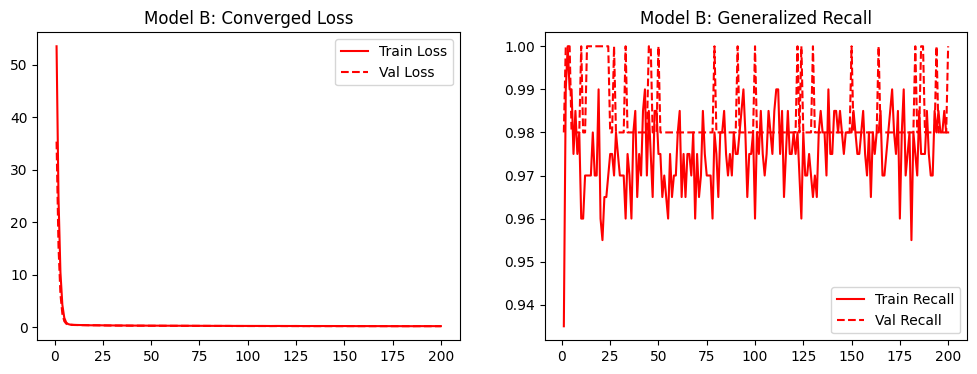

In [23]:
# Write your Engineered Model code here
from tensorflow.keras import regularizers
model_B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(512, kernel_regularizer=regularizers.l2(0.2)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dropout(0.4),
    
    # Layer 2 with L2 and Dropout
    tf.keras.layers.Dense(256, kernel_regularizer=regularizers.l2(0.2)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_B.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.Recall(name='recall')]
)

# EarlyStopping stops before overfitting begins
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history_B = model_B.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200, batch_size=16, 
    callbacks=[early_stop], verbose=0
)

# Plotting solution curves
epochs_B = range(1, len(history_B.history['loss']) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_B, history_B.history['loss'], label='Train Loss', color='red')
plt.plot(epochs_B, history_B.history['val_loss'], label='Val Loss', ls='--', color='red')
plt.title("Model B: Converged Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_B, history_B.history['recall'], label='Train Recall', color='red')
plt.plot(epochs_B, history_B.history['val_recall'], label='Val Recall', ls='--', color='red')
plt.title("Model B: Generalized Recall")
plt.legend()
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

═══════════════════════════════════════════════════════
  Model A (Baseline — SGD, No Regularisation)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Not CKD       0.91      1.00      0.95        30
         CKD       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg       0.95      0.97      0.96        80
weighted avg       0.97      0.96      0.96        80

═══════════════════════════════════════════════════════
  Model B (Regularised — Adam + L2 + Dropout)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



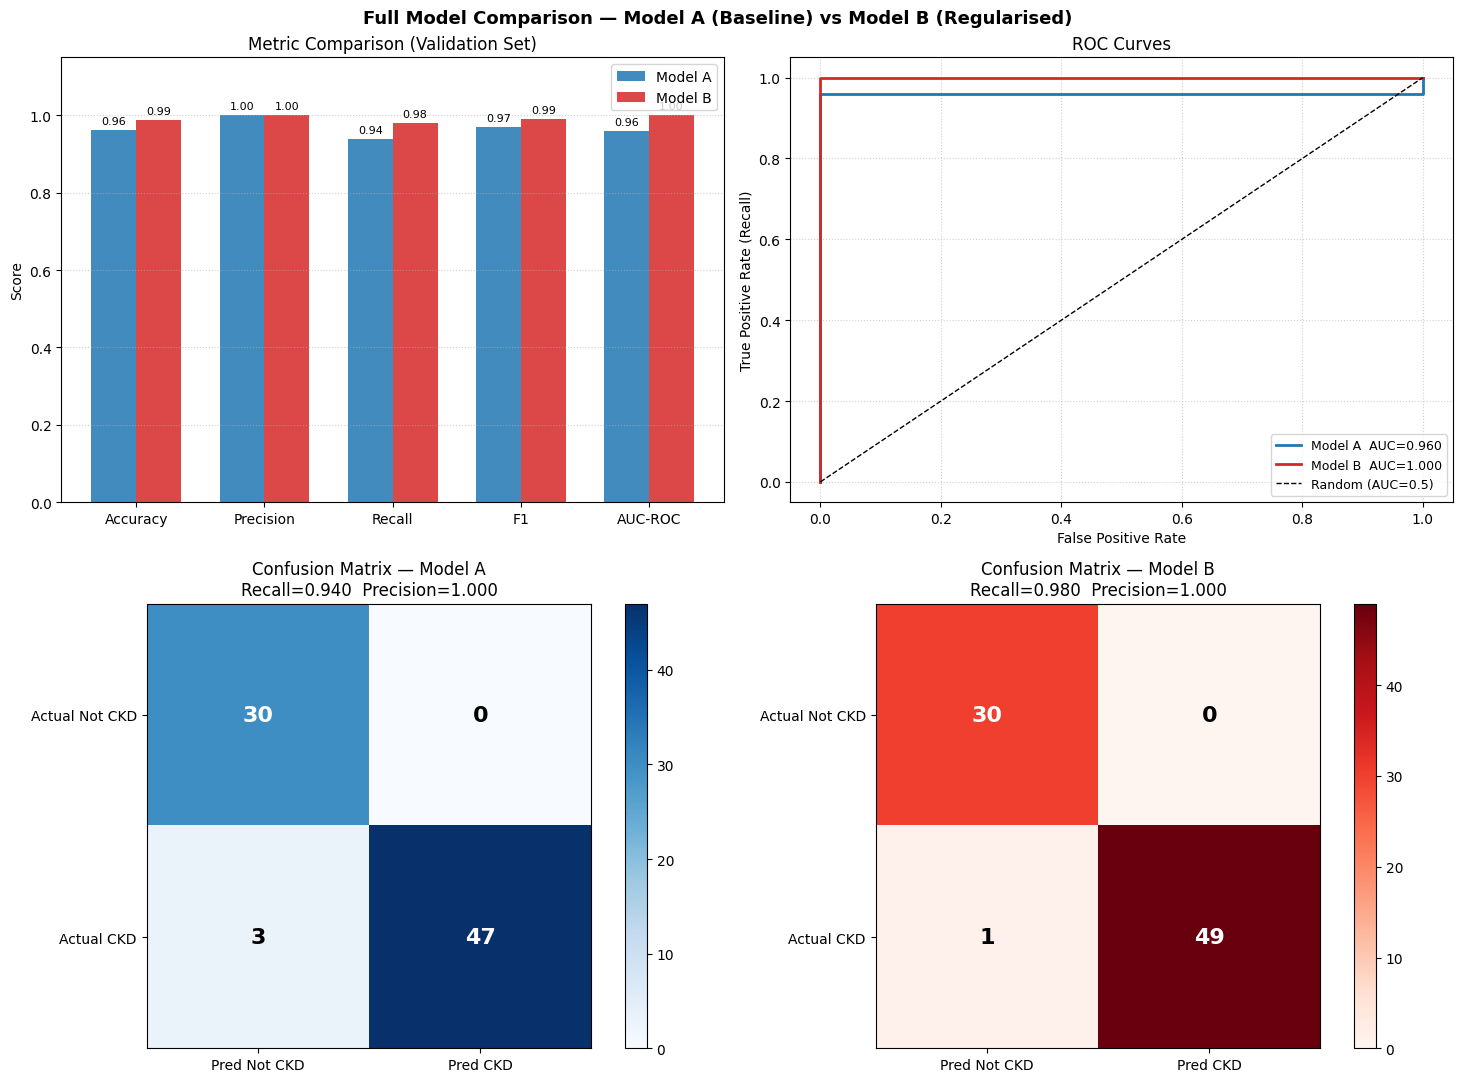


 Model B − Model A (validation set)
  Accuracy    : 0.9625  →  0.9875   ▲ 0.0250
  Precision   : 1.0000  →  1.0000   ─ 0.0000
  Recall      : 0.9400  →  0.9800   ▲ 0.0400
  F1          : 0.9691  →  0.9899   ▲ 0.0208
  AUC-ROC     : 0.9600  →  1.0000   ▲ 0.0400

Figure saved → model_comparison.png

Clinical Benchmark
  Model B Recall = 0.9800
  Target > 0.80  : PASSED ✓

 Model B Total Trainable Parameters: 137729


In [26]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_curve, auc,
)

# Hard predictions (threshold = 0.5)
y_pred_A_prob = model_A.predict(X_val_scaled, verbose=0).ravel()
y_pred_B_prob = model_B.predict(X_val_scaled, verbose=0).ravel()

y_pred_A = (y_pred_A_prob >= 0.5).astype(int)
y_pred_B = (y_pred_B_prob >= 0.5).astype(int)

# Helper: collect all scalar metrics + ROC data
def compute_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC"  : auc(fpr, tpr),
        "fpr"      : fpr,
        "tpr"      : tpr,
    }

metrics_A = compute_metrics(y_val, y_pred_A, y_pred_A_prob)
metrics_B = compute_metrics(y_val, y_pred_B, y_pred_B_prob)

# Classification Report 
print("═" * 55)
print("  Model A (Baseline — SGD, No Regularisation)")
print("═" * 55)
print(classification_report(y_val, y_pred_A, target_names=["Not CKD", "CKD"]))

print("═" * 55)
print("  Model B (Regularised — Adam + L2 + Dropout)")
print("═" * 55)
print(classification_report(y_val, y_pred_B, target_names=["Not CKD", "CKD"]))

BLUE, RED = "#1f77b4", "#d62728"
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Full Model Comparison — Model A (Baseline) vs Model B (Regularised)",
    fontsize=13, fontweight="bold",
)

x      = np.arange(len(metric_keys))
bar_w  = 0.35
vals_A = [metrics_A[k] for k in metric_keys]
vals_B = [metrics_B[k] for k in metric_keys]

bars_A = axes[0, 0].bar(x - bar_w / 2, vals_A, bar_w, label="Model A", color=BLUE, alpha=0.85)
bars_B = axes[0, 0].bar(x + bar_w / 2, vals_B, bar_w, label="Model B", color=RED,  alpha=0.85)

for bar in bars_A:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metric_keys)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Metric Comparison (Validation Set)")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)


axes[0, 1].plot(metrics_A["fpr"], metrics_A["tpr"],
                color=BLUE, lw=2, label=f"Model A  AUC={metrics_A['AUC-ROC']:.3f}")
axes[0, 1].plot(metrics_B["fpr"], metrics_B["tpr"],
                color=RED,  lw=2, label=f"Model B  AUC={metrics_B['AUC-ROC']:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.5)")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title("ROC Curves")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)


cm_A = confusion_matrix(y_val, y_pred_A)
im_A = axes[1, 0].imshow(cm_A, interpolation="nearest", cmap="Blues")
axes[1, 0].set_title(
    f"Confusion Matrix — Model A\n"
    f"Recall={metrics_A['Recall']:.3f}  Precision={metrics_A['Precision']:.3f}"
)
for i in range(2):
    for j in range(2):
        axes[1, 0].text(
            j, i, str(cm_A[i, j]), ha="center", va="center", fontsize=16,
            fontweight="bold",
            color="white" if cm_A[i, j] > cm_A.max() / 2 else "black",
        )
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["Pred Not CKD", "Pred CKD"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["Actual Not CKD", "Actual CKD"])
plt.colorbar(im_A, ax=axes[1, 0])


cm_B = confusion_matrix(y_val, y_pred_B)
im_B = axes[1, 1].imshow(cm_B, interpolation="nearest", cmap="Reds")
axes[1, 1].set_title(
    f"Confusion Matrix — Model B\n"
    f"Recall={metrics_B['Recall']:.3f}  Precision={metrics_B['Precision']:.3f}"
)
for i in range(2):
    for j in range(2):
        axes[1, 1].text(
            j, i, str(cm_B[i, j]), ha="center", va="center", fontsize=16,
            fontweight="bold",
            color="white" if cm_B[i, j] > cm_B.max() / 2 else "black",
        )
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(["Pred Not CKD", "Pred CKD"])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(["Actual Not CKD", "Actual CKD"])
plt.colorbar(im_B, ax=axes[1, 1])

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()


print("\n Model B − Model A (validation set)")
for k in metric_keys:
    delta = metrics_B[k] - metrics_A[k]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {k:<12}: {metrics_A[k]:.4f}  →  {metrics_B[k]:.4f}   {direction} {abs(delta):.4f}")

print(f"\nFigure saved → model_comparison.png")
print(f"\nClinical Benchmark")
print(f"  Model B Recall = {metrics_B['Recall']:.4f}")
print(f"  Target > 0.80  : {'PASSED ✓' if metrics_B['Recall'] >= 0.80 else 'FAILED ✗'}")

# Print final parameter count for the justification cell
total_B = model_B.count_params()
print(f"\n Model B Total Trainable Parameters: {total_B}")


### Mathematical Justification

$$\text{Params} = (\text{Input} \times \text{Neurons}) + \text{Neurons}$$

| Layer | Input | Neurons | Params |
|---|---|---|---|
| Dense(512) | 11 | 512 | **6,144** |
| Dense(256) | 512 | 256 | **131,328** |
| Dense(1)   | 256 | 1   | **257** |
| **TOTAL**  |     |     | **137,729** |

**Final Parameter Count: 137,729**

L2 regularisation penalises large weights while 40%/30% Dropout randomly disables neurons each update, together preventing any fixed memorisation path from encoding the 400-patient training set rather than generalised CKD biomarkers.